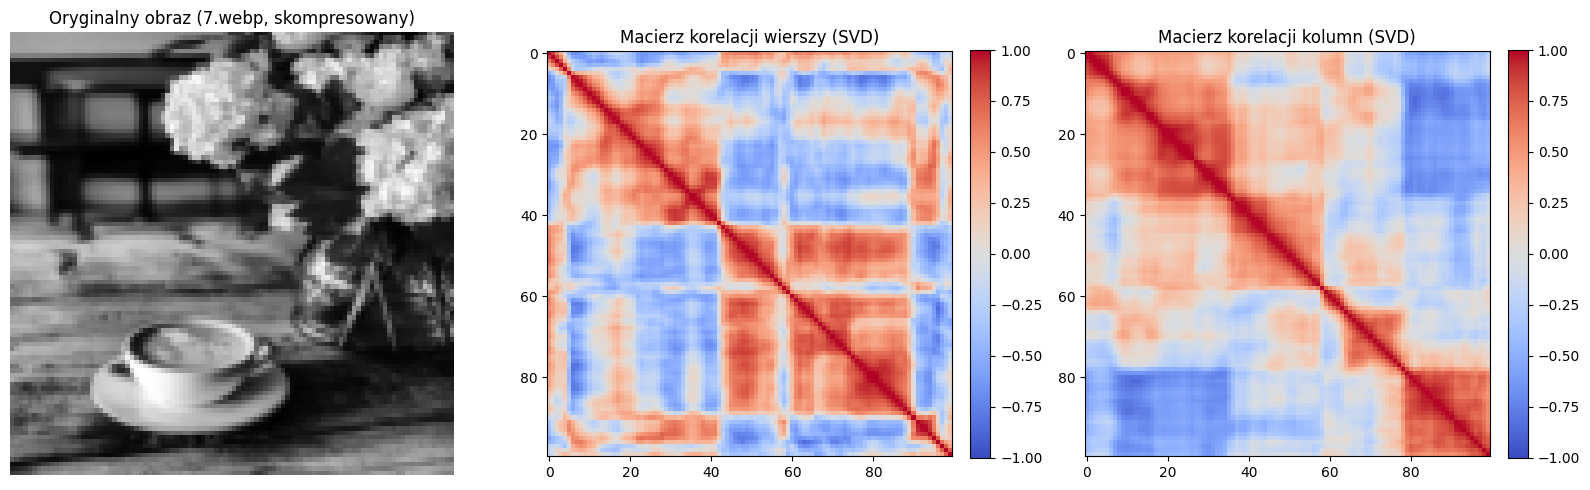

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, transform

img_raw = io.imread('7.webp')

if img_raw.ndim >= 3:
    img = color.rgb2gray(img_raw[..., :3])
else:
    img = img_raw

img = transform.resize(img, (100, 100))

img_row_centered = img - np.mean(img, axis=1, keepdims=True)
img_row_std = np.std(img_row_centered, axis=1, keepdims=True)
img_row_std[img_row_std == 0] = 1 
img_row_norm = img_row_centered / (img_row_std * np.sqrt(img.shape[1] - 1))

U_r, S_r, Vt_r = np.linalg.svd(img_row_norm, full_matrices=False)
corr_rows = U_r @ np.diag(S_r**2) @ U_r.T

img_col_centered = img - np.mean(img, axis=0, keepdims=True)
img_col_std = np.std(img_col_centered, axis=0, keepdims=True)
img_col_std[img_col_std == 0] = 1
img_col_norm = img_col_centered / (img_col_std * np.sqrt(img.shape[0] - 1))

U_c, S_c, Vt_c = np.linalg.svd(img_col_norm, full_matrices=False)
corr_cols = Vt_c.T @ np.diag(S_c**2) @ Vt_c

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Oryginalny obraz (7.webp, skompresowany)')
axes[0].axis('off')

im1 = axes[1].imshow(corr_rows, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Macierz korelacji wierszy (SVD)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(corr_cols, cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_title('Macierz korelacji kolumn (SVD)')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()